In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [2]:
print("Hello from do-it!")

Hello from do-it!


In [3]:
diabetes = load_diabetes()
print(diabetes.data.shape, diabetes.target.shape)

(442, 10) (442,)


In [4]:
diabetes.data[0:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

In [5]:
diabetes.target[0:3]

array([151.,  75., 141.])

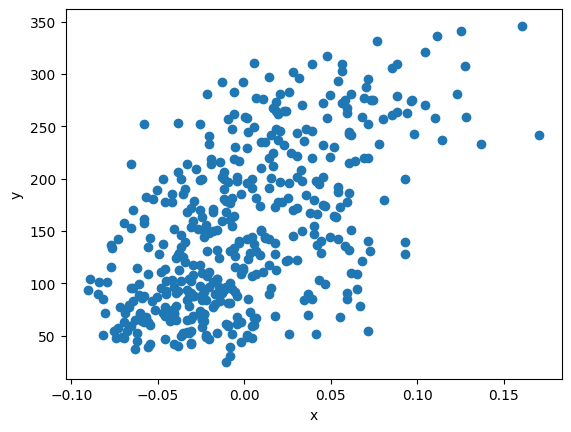

In [6]:
plt.scatter(diabetes.data[:, 2], diabetes.target)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [7]:
x = diabetes.data[:, 2]
y = diabetes.target
w = 1.0
b = 1.0

In [8]:
y_hat = x[0] * w + b
print(y_hat)

1.0616962065186832


In [9]:
w_inc = w + 0.1
y_hat_inc = x[0] * w_inc + b
print(y_hat_inc)

1.0678658271705517


In [10]:
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
print(w_rate)

0.06169620651868429


In [11]:
w_new = w + w_rate
print(w_new)

1.0616962065186843


In [12]:
b_inc = b + 0.1
y_hat_inc = x[0] * w + b_inc
print(y_hat_inc)

b_rate = (y_hat_inc - y_hat) / (b_inc - b)
print(b_rate)

1.1616962065186833
1.0


In [13]:
b_new = b + b_rate
print(b_new)

2.0


In [14]:
## 1st sample
## 이전에 구한 첫번째 y_hat
err = y[0] - y_hat
w_new = w + w_rate * err
b_new = b + b_rate * err
print(w_new, b_new)

10.250624555903848 150.9383037934813


In [15]:
## 2nd sample
y_hat = x[1] * w_new + b_new
err = y[1] - y_hat
w_rate = x[1]
w_new = w_new + w_rate * err
b_new = b_new + b_rate * err
print(w_new, b_new)

14.132317616380695 75.52764127612656


In [16]:
## 3rd sample
y_hat = x[2] * w_new + b_new
err = y[2] - y_hat
w_rate = x[2]
w_new = w_new + w_rate * err
b_new = b_new + b_rate * err
print(w_new, b_new)

17.014719208776086 140.3718013346938


In [17]:
## for all samples
i = 0
for x_i, y_i in zip(x, y):
    y_hat = x_i * w + b
    err = y_i - y_hat
    w_rate = x_i
    w = w + w_rate * err
    b = b + b_rate * err
    i += 1
    # if i == 3:
    #     print("3rd sample check")
    #     print(w, b)
print(w, b, i)


587.8654539985616 99.4093556453094 442


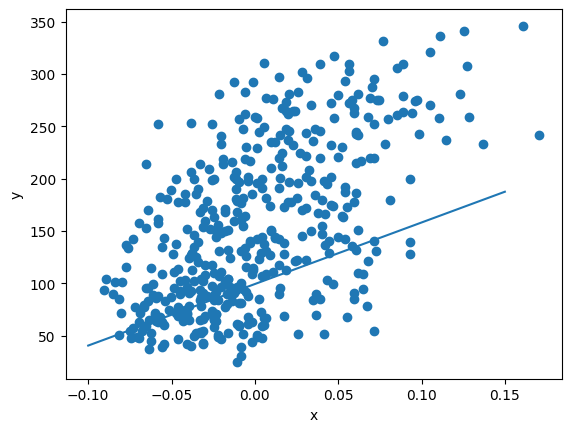

In [18]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [19]:
## 100 epoch repeat
for i in range(1, 100):
    for x_i, y_i in zip(x, y):
        y_hat = x_i * w + b
        err = y_i - y_hat
        w_rate = x_i
        w = w + w_rate * err
        b = b + b_rate * err
        i += 1
print(w, b)

913.5973364346786 123.39414383177173


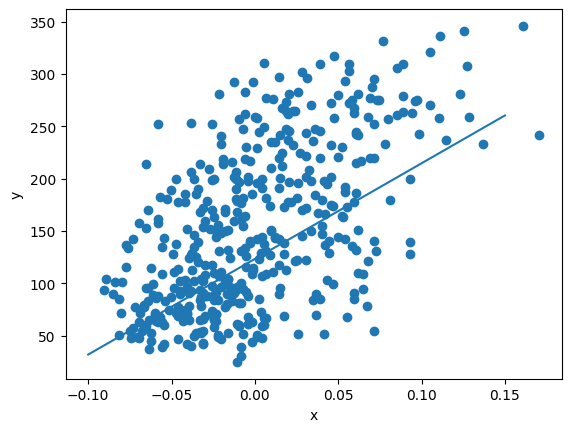

In [20]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [21]:
## infer
x_new = 0.18
y_pred = x_new * w + b
print(y_pred)

287.8416643900139


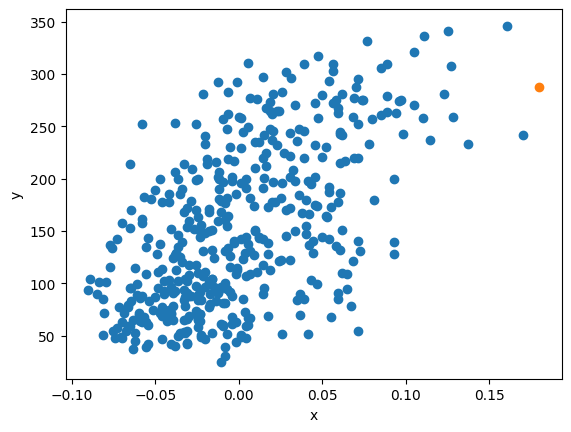

In [22]:
plt.scatter(x,y)
plt.scatter(x_new, y_pred)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [23]:
# Loss function & Gradient descent
y_hat = x_i * w + b
err = y_i - y_hat
w_rate = x_i

err = y_i - y_hat
b = b + 1 * err

In [24]:
# Neuron class
class Neuron:
    def __init__(self):
        # initial setup
        self.w = 1.0
        self.b = 1.0

    def forward(self, x):
        y_hat = x * self.w + self.b
        return y_hat

    def backpropagation(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad

    def fit(self, x, y, epochs = 100):
        for i in range(epochs):
            for x_i, y_i in zip(x, y):
                y_hat = self.forward(x_i)
                err = -(y_i - y_hat)
                w_grad, b_grad = self.backpropagation(x_i, err)
                self.w -= w_grad
                self.b -= b_grad

In [25]:
neuron = Neuron()
neuron.fit(x, y)

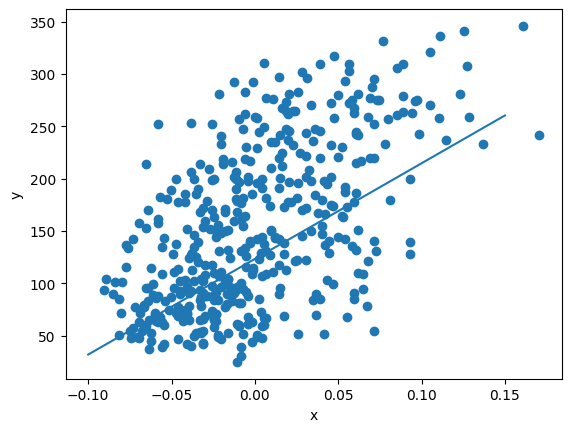

In [26]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * neuron.w + neuron.b)
pt2 = (0.15, 0.15 * neuron.w + neuron.b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [27]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(cancer.data.shape, cancer.target.shape)

(569, 30) (569,)


In [28]:
cancer.data[:3]

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
        8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
        3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
        1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
        1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01, 1.599e-01,
        1.974e-01, 1.279e-01, 2.069e-01, 5.999e-02, 7.456e-01, 7.869e-01,
        4.585e+00, 9.403e+01, 6.150e-03, 4.006e-02, 3.832e-02, 2.058e-02,
        2.250e-02, 4.571e-03, 2.357e

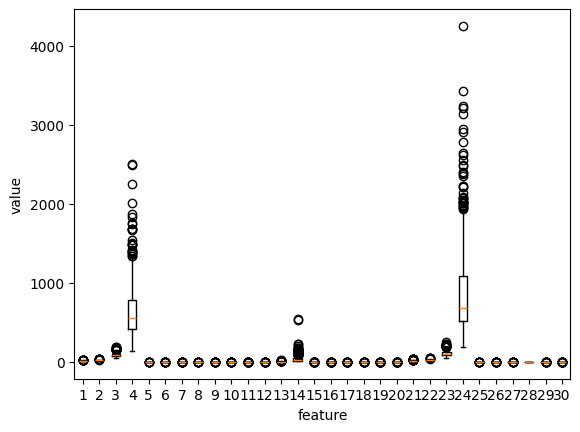

In [29]:
plt.boxplot(cancer.data)
plt.xlabel('feature')
plt.ylabel('value')
plt.show()

In [30]:
cancer.feature_names[[3, 13, 23]]

array(['mean area', 'area error', 'worst area'], dtype='<U23')

In [31]:
np.unique(cancer.target, return_counts=True)

(array([0, 1]), array([212, 357]))

In [32]:
cancer_x = cancer.data
cancer_y = cancer.target

In [33]:
## 훈련 데이터 "잘" 나누기
## 비율을 맞춰 골고루 잘 나눠주기
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(cancer_x, cancer_y, stratify=cancer_y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(455, 30) (114, 30)


In [34]:
## 잘 나뉘었는지 확인
np.unique(y_train, return_counts=True)

(array([0, 1]), array([170, 285]))

In [35]:
class LogisticNeuron:
    def __init__(self):
        self.w = None
        self.b = None
    
    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z

    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad

    def activation(self, z):
        a = 1 / (1 + np.exp(-z))
        return a

    def fit(self, x, y, epochs=100):
        print(f"input x.shape = {x.shape}")
        self.w = np.ones(x.shape[1])
        self.b = 0

        for i in range(epochs):
            for x_i, y_i in zip(x, y):
                z = self.forpass(x_i)
                a = self.activation(z)
                err = -(y_i - a)
                w_grad, b_grad = self.backprop(x_i, err)
                self.w -= w_grad
                self.b -= b_grad

    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        a = self.activation(np.array(z))
        return a > 0.5

In [36]:
neuron = LogisticNeuron()
neuron.fit(x_train, y_train)

input x.shape = (455, 30)


C:\Users\USER\AppData\Local\Temp\ipykernel_6240\4125771506.py:16: RuntimeWarning: overflow encountered in exp
  a = 1 / (1 + np.exp(-z))


In [37]:
np.mean(neuron.predict(x_test) == y_test)

C:\Users\USER\AppData\Local\Temp\ipykernel_6240\4125771506.py:16: RuntimeWarning: overflow encountered in exp
  a = 1 / (1 + np.exp(-z))


np.float64(0.8245614035087719)

In [38]:
# accuracy = 0.8245614035087719 (82%)
# Next is SingleLayer Class
class SingleLayer:
    def __init__(self):
        self.w = None
        self.b = None
        self.losses = []
    
    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z

    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad

    def add_bias(self, x):
        # 행렬의 맨 앞에 1로 채워진 열 벡터를 추가합니다
        return np.c_[np.ones((x.shape[0], 1)), x]

    def activation(self, z):
        a = 1 / (1 + np.exp(-z))
        return a

    def fit(self, x, y, epochs=100):
        self.w = np.ones(x.shape[1])
        self.b = 0

        for i in range(epochs):
            loss = 0
            indexes = np.random.permutation(np.arange(len(x)))
            for i in indexes:
                z = self.forpass(x[i])
                a = self.activation(z)
                err = -(y[i] - a)
                w_grad, b_grad = self.backprop(x[i], err)
                self.w -= w_grad
                self.b -= b_grad

                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a)+(1-y[i])*np.log(1-a))

            self.losses.append(loss/len(y))

    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        return np.array(z) > 0

    def score(self, x, y):
        return np.mean(self.predict(x) == y)

In [39]:
layer = SingleLayer()
layer.fit(x_train, y_train)
layer.score(x_test, y_test)

C:\Users\USER\AppData\Local\Temp\ipykernel_6240\37113918.py:23: RuntimeWarning: overflow encountered in exp
  a = 1 / (1 + np.exp(-z))


np.float64(0.9210526315789473)

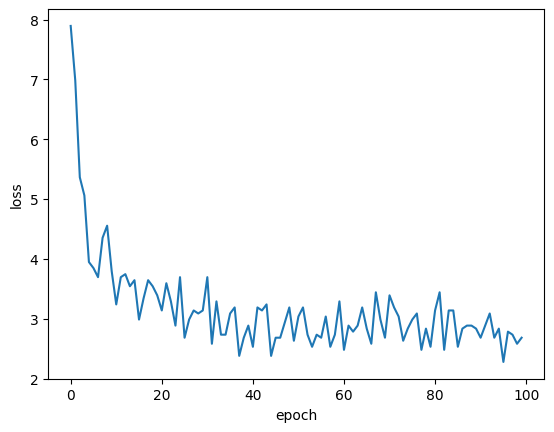

In [40]:
plt.plot(layer.losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [41]:
from sklearn.linear_model import SGDClassifier
# loss = {'perceptron', 'hinge', 'log_loss', 'huber', 'squared_error', 'squared_hinge', 'modified_huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}
sgd = SGDClassifier(loss='perceptron', max_iter=100, tol=1e-3, random_state=42)
sgd.fit(x_train, y_train)
sgd.score(x_test, y_test)

0.9210526315789473